# Evaluation

In [1]:
import itertools
import json
import pathlib

import itables
import matplotlib.pyplot as plt
import numpy
import pandas

In [2]:
INPUT_DIRS = ['machines']
INPUT = list(itertools.chain(*map(lambda x: pathlib.Path(x).glob('*.txt'), INPUT_DIRS)))

## Info

In [3]:
import evaluate
MACHINES = evaluate._um_read_stats_as_dataframe(INPUT)
itables.show(MACHINES)

Loading ITables v2.8.0 from the internet... (need help?)


## Runs

In [4]:
# last updated: 2026-06-05
PRICING = {
    # https://platform.claude.com/docs/en/about-claude/pricing
    'anthropic': {
        'claude-opus-4-8': (5./1e6, 25./1e6),
        'claude-opus-4-7': (5./1e6, 25./1e6),
    },
    # https://api-docs.deepseek.com/quick_start/pricing/
    'deepseek': {
        'deepseek-v4-pro':   (.435/1e6, .87/1e6), 
        'deepseek-v4-flash': (.14/1e6,  .28/1e6), 
    },
    # https://ai.google.dev/gemini-api/docs/pricing
    'google-genai': {
        'gemini-3.1-pro-preview': (4./1e6, 18./1e6),
        'gemini-2.5-pro':         (2.5/1e6, 15./1e6),
    },
    # https://developers.openai.com/api/docs/pricing
    'openai': {
        'gpt-5.5':      (5.0/1e6,  30./1e6),
        'gpt-5.4':      (2.5/1e6,  15./1e6), 
        'gpt-5.2':      (1.75/1e6, 14./1e6),
        'gpt-5.4-mini': (.75/1e6,  4.5/1e6),
        'gpt-5.4-nano': (.20/1e6,  1.25/1e6)}}

def cost(provider, model, input_tokens, output_tokens):
    try:
        l, r = PRICING[provider][model]
        return l * input_tokens + r * output_tokens
    except KeyError as err:
        return 0.

In [5]:
def load(runs, skip=lambda x: False):
    for path in runs:
        with open(path, 'rt', encoding='utf-8') as fp:
            t = json.load(fp)
            if skip(t):
                continue
            yield {
                #'path': str(path),
                'D': t['digest'],
                'Q': t['num_states'],
                'S': t['num_symbols'],
                'W': t['work_length'],
                'C': t['cycles_until_halt'],
                'provider': t['provider'],
                'model': t['model'] + ('' if t['truncate'] is None else '(tr)'),
                #'prompt': t['prompt'],
                #'temperature': t['temperature'],
                #'seed': t['seed'],
                'truncate': f'yes({t["truncate"]})' if t['truncate'] is not None else 'no',
                'cycles': t['cycles'],
                'progress': t['cycles'] / t['cycles_until_halt'],
                'error': bool(t['error']),
                'halted': bool(t['halted']),
                'input_tokens': t['usage_metadata']['input_tokens'],
                'output_tokens': t['usage_metadata']['output_tokens'],
                'cost': cost(t['provider'],
                             t['model'],
                             t['usage_metadata']['input_tokens'],
                             t['usage_metadata']['output_tokens']),
            }

In [6]:
OUTPUT_DIRS = ['runs']
OUTPUT = list(itertools.chain(*map(lambda x: pathlib.Path(x).glob('*.json'), OUTPUT_DIRS)))
SKIP = lambda t: t['model'] in ('claude-opus-4-8', 'gpt-5.5')
RUNS = pandas.DataFrame(list(load(OUTPUT, SKIP)))
RUNS_SUM = RUNS[['error', 'halted']].sum().to_frame(name='sum')
RUNS_COST = RUNS[['cost']].sum().to_frame(name='$')
display(RUNS_SUM)
display(RUNS_COST)
itables.show(RUNS.sort_values(by=['progress', 'cycles'], ascending=False))

,sum
error,583
halted,160


,$
cost,235.022464


Loading ITables v2.8.0 from the internet... (need help?)


## Runs per model

In [7]:
CFG_Ds = sorted(RUNS['D'].unique())
CFG_Qs = sorted(RUNS['Q'].unique())
CFG_Ss = sorted(RUNS['S'].unique())
CFG_Ws = sorted(RUNS['W'].unique())
CFG_Cs = sorted(RUNS['C'].unique())
CFG_MODELS = sorted(RUNS['model'].unique())
RUNS_PER_MODEL = {model: RUNS[RUNS['model'] == model] for model in CFG_MODELS}

In [8]:
RUNS_PER_MODEL_STATS = pandas.DataFrame([{'model': k, 'runs': len(t), '%': len(t) / len(MACHINES) * 100} for k, t in RUNS_PER_MODEL.items()])
RUNS_PER_MODEL_STATS

,model,runs,%
0,deepseek-v4-pro,116,100.000000
1,deepseek-v4-pro(tr),79,68.103448
2,gemini-2.5-pro,84,72.413793
3,gpt-5.2,116,100.000000
4,gpt-5.2(tr),116,100.000000
5,gpt-5.4,116,100.000000
6,gpt-5.4(tr),116,100.000000


## Progress

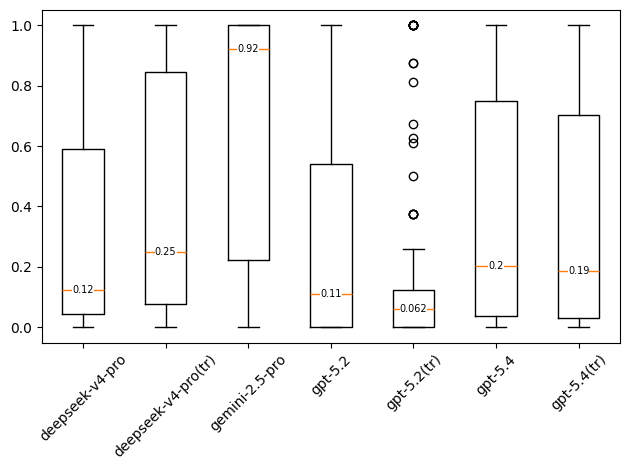

In [9]:
fig, ax = plt.subplots()
labels, data = list(zip(*((k, t['progress']) for k, t in RUNS_PER_MODEL.items())))
bp = ax.boxplot(data, tick_labels=labels)
for line in bp['medians']:
    xs, ys = line.get_xdata(), line.get_ydata()
    x, y = numpy.mean(xs), numpy.mean(ys)
    if not numpy.isnan(y):
        ax.annotate(
            f'{y:.2g}' if (y < 1.) else f'{round(y)}',
            (x, y), ha='center', va='center',
            color='black', fontsize=7, bbox={
                'boxstyle': 'square,pad=.01',
                'facecolor': 'white',
                'linewidth': .0})
ax.tick_params(axis='x', labelrotation=45)
fig.tight_layout()
plt.show()

In [10]:
pandas.DataFrame({'model': k, 'median progress': v['progress'].median()} for k, v in RUNS_PER_MODEL.items()).sort_values(by=['median progress'], ascending=False)

,model,median progress
2,gemini-2.5-pro,0.921875
1,deepseek-v4-pro(tr),0.250000
5,gpt-5.4,0.203125
6,gpt-5.4(tr),0.187500
0,deepseek-v4-pro,0.125000
3,gpt-5.2,0.109375
4,gpt-5.2(tr),0.062500


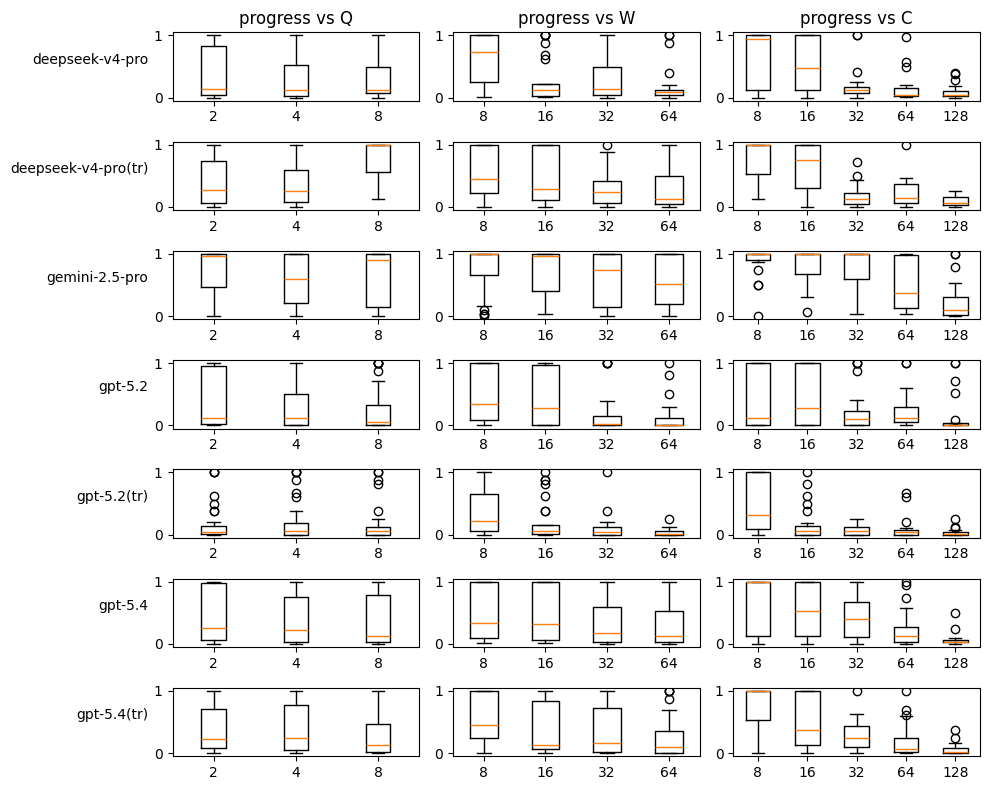

In [11]:
fig = plt.figure(figsize=(10,8))
nrows, ncols = len(RUNS_PER_MODEL), 3
for i, (k, t) in enumerate(RUNS_PER_MODEL.items()):
    axQ = fig.add_subplot(nrows, ncols, i * ncols + 1)
    axQ.boxplot([t[t['Q'] == n]['progress'] for n in CFG_Qs], tick_labels=CFG_Qs)
    axW = fig.add_subplot(nrows, ncols, i * ncols + 2)
    axW.boxplot([t[t['W'] == n]['progress'] for n in CFG_Ws], tick_labels=CFG_Ws)
    axC = fig.add_subplot(nrows, ncols, i * ncols + 3)
    axC.boxplot([t[t['C'] == n]['progress'] for n in CFG_Cs], tick_labels=CFG_Cs)
    if i == 0:
        axQ.set_title('progress vs Q')
        axW.set_title('progress vs W')
        axC.set_title('progress vs C')
    axQ.set_ylabel(k, rotation=0, ha='right')
fig.tight_layout()

## Accuracy

In [12]:
def it():
    N = list(range(0, CFG_Cs[-1] + 1))
    for k, t in RUNS_PER_MODEL.items(): 
        N_correct = pandas.Series([len(t[t['cycles'] >= i]) for i in N])
        N_total = pandas.Series([len(t[t['C'] >= i]) for i in N])
        yield pandas.DataFrame(N_correct / N_total, columns=[k])
ACC = pandas.concat(it(), axis=1)
ACC

,deepseek-v4-pro,deepseek-v4-pro(tr),gemini-2.5-pro,gpt-5.2,gpt-5.2(tr),gpt-5.4,gpt-5.4(tr)
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.965517,0.924051,0.964286,0.724138,0.706897,0.905172,0.887931
2,0.775862,0.873418,0.904762,0.560345,0.500000,0.801724,0.750000
3,0.672414,0.810127,0.892857,0.551724,0.413793,0.732759,0.663793
4,0.612069,0.784810,0.892857,0.525862,0.344828,0.663793,0.612069
...,...,...,...,...,...,...,...
124,0.000000,0.000000,0.125000,0.090909,0.000000,0.000000,0.000000
125,0.000000,0.000000,0.125000,0.090909,0.000000,0.000000,0.000000
126,0.000000,0.000000,0.125000,0.090909,0.000000,0.000000,0.000000
127,0.000000,0.000000,0.125000,0.090909,0.000000,0.000000,0.000000


<Axes: >

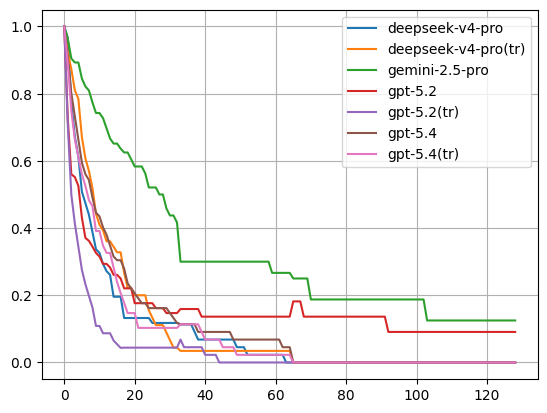

In [13]:
ACC.plot.line(grid=True)

<Axes: >

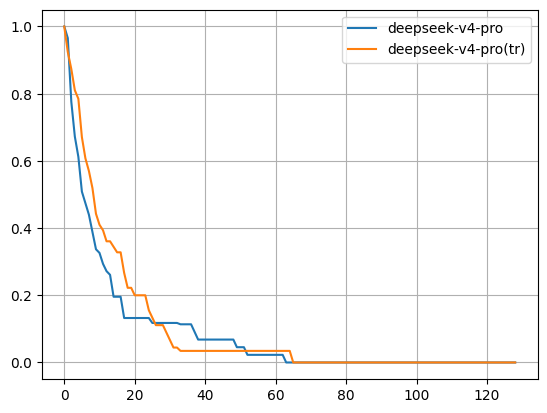

In [16]:
ACC[['deepseek-v4-pro', 'deepseek-v4-pro(tr)']].plot.line(grid=True)

<Axes: >

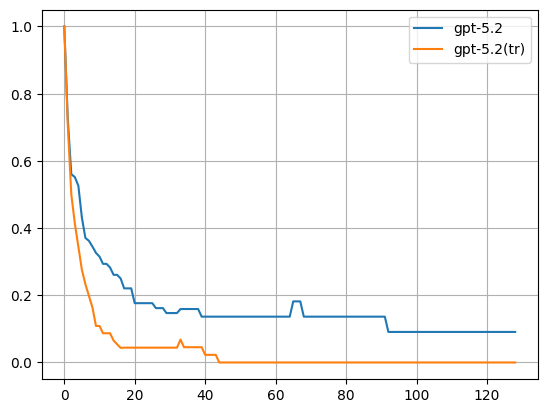

In [17]:
ACC[['gpt-5.2', 'gpt-5.2(tr)']].plot.line(grid=True)

<Axes: >

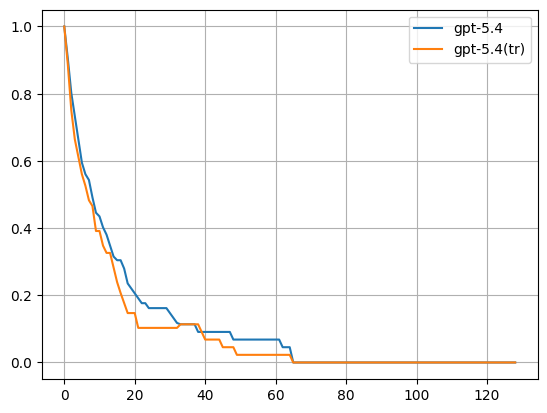

In [18]:
ACC[['gpt-5.4', 'gpt-5.4(tr)']].plot.line(grid=True)

# Variants

In [19]:
import evaluate
HALTED_RUNS = RUNS[RUNS['halted'] == True]
ALL_MODELS = set(CFG_MODELS)
SRC_Ds = [d for d in HALTED_RUNS['D'].unique() if set(HALTED_RUNS[HALTED_RUNS['D'] == d]['model'].values) == ALL_MODELS]
SRC_Ds

['3697aba8466a1891198569358e2784441c62b22887b9efb0257e7bd9156e4179']

In [16]:
SRC_PATHS = [next(pathlib.Path('machines').glob(f'*-{d}.txt')) for d in SRC_Ds]
VARDIR = pathlib.Path('machines.variants')
VARDIR.mkdir(exist_ok=True)
for path in SRC_PATHS:
    varpath = VARDIR / (path.stem + '-variant.txt')
    print('writting variant ', varpath)
    evaluate._um_gen_variant(path).dump_file(varpath)

writting variant  machines.variants/Q08-S02-W08-C16-21d92f377c149374e918c2b034ed2bb407ed1ab90d45c7c7dfe4effaf9d14f57-variant.txt
writting variant  machines.variants/Q08-S02-W08-C08-3697aba8466a1891198569358e2784441c62b22887b9efb0257e7bd9156e4179-variant.txt
writting variant  machines.variants/Q02-S02-W08-C08-96eb57514d2ab41c6c8a3d74e28c23429fc9c3cd04cd5b04fbaa48d18d5e4cc4-variant.txt
writting variant  machines.variants/Q04-S02-W08-C08-14c8349936deb77fd7cbf16af98ad70b4d76ee400b47583781961cb977d451d0-variant.txt


In [17]:
VAR_OUTPUT_DIRS = ['runs.variants']
VAR_OUTPUT = list(itertools.chain(*map(lambda x: pathlib.Path(x).glob('*.json'), VAR_OUTPUT_DIRS)))
VARS = pandas.DataFrame(list(load(VAR_OUTPUT)))
itables.show(VARS)

Loading ITables v2.8.0 from the internet... (need help?)
